In [1]:
from environments.EMS_env import ContinousEMSEnv, normalizationWrapper
import gymnasium as gym
import numpy as np
from stable_baselines3 import TD3, PPO, SAC
from stable_baselines3.common.noise import NormalActionNoise, OrnsteinUhlenbeckActionNoise
import matplotlib.pyplot as plt
from stable_baselines3.common.logger import configure
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'cm'

In [14]:
tmp_path = "training_results/ems"
algorithms = ["PPO", "TD3", "SAC"]
env = ContinousEMSEnv()
env = normalizationWrapper(env)
s, _ = env.reset()

/home/pc5/anaconda3/envs/RL/lib/python3.8/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.action_high to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.action_high` for environment variables or `env.get_wrapper_attr('action_high')` that will search the reminding wrappers.
  logger.warn(


In [3]:
# run experiments
n_actions = env.action_space.shape[-1]

for alg in algorithms:
    model = None
    if alg == "PPO":
        model = PPO("MlpPolicy", env, verbose=1, learning_rate=3e-4, batch_size=128)
    elif alg == "TD3":
        action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))
        model = TD3("MlpPolicy", env,action_noise=action_noise, verbose=1, learning_rate=3e-4, batch_size=128)
    elif alg == "SAC":
        model = SAC("MlpPolicy", env, verbose=1, learning_rate=3e-4, batch_size=128)
    new_logger = configure(tmp_path+"/ems/"+alg, ["stdout", "csv", "tensorboard"])
    model.set_logger(new_logger)
    model.learn(total_timesteps=2_000_000, log_interval=10)
    try:
        model.save(tmp_path+"/ems/"+alg+f"/{alg}_du_norm_1")
    except:
        model.save(alg)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to training_results/ems/ems/PPO
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 288          |
|    ep_rew_mean          | -225         |
| time/                   |              |
|    fps                  | 885          |
|    iterations           | 10           |
|    time_elapsed         | 23           |
|    total_timesteps      | 20480        |
| train/                  |              |
|    approx_kl            | 0.0043644225 |
|    clip_fraction        | 0.0309       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.58        |
|    explained_variance   | -0.00171     |
|    learning_rate        | 0.0003       |
|    loss                 | 21           |
|    n_updates            | 90           |
|    policy_gradient_loss | -0.00529     |
|    std                  | 0.885        |
|    

In [3]:
directories = ['training_results/ems/ems/PPO/progress.csv',
               'training_results/ems/ems/TD3/progress.csv',
               'training_results/ems/ems/SAC/progress.csv']
ppo_stats = pd.read_csv(directories[0])
td3_stats = pd.read_csv(directories[1])
sac_stats = pd.read_csv(directories[2])

In [4]:
ppo_rews = ppo_stats['rollout/ep_rew_mean'].to_numpy()
td3_rews = td3_stats['rollout/ep_rew_mean'].to_numpy()
sac_rews = sac_stats['rollout/ep_rew_mean'].to_numpy()

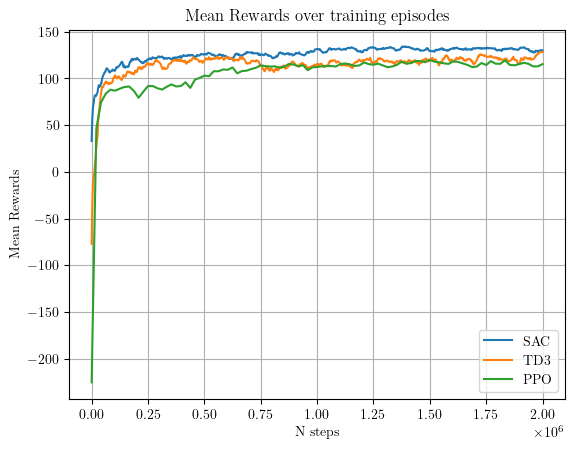

In [12]:
n1 = np.linspace(1,2e6, len(ppo_stats))
n2 = np.linspace(1,2e6, len(td3_stats))
n3 = np.linspace(1,2e6, len(sac_stats))
plt.plot(n3, sac_rews, label = 'SAC')
plt.plot(n2, td3_rews, label = 'TD3')
plt.plot(n1, ppo_rews, label = 'PPO')
plt.title('Mean Rewards over training episodes')
plt.legend()
plt.xlabel('N steps')
plt.ylabel('Mean Rewards')
plt.grid()
plt.savefig('learning_curves.png', dpi = 300)

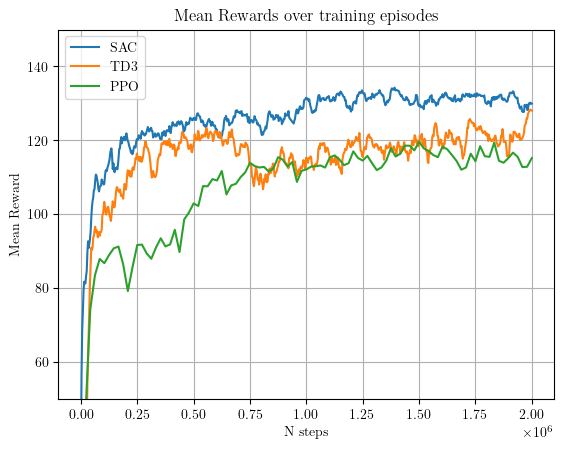

In [11]:
n1 = np.linspace(1,2e6, len(ppo_stats))
n2 = np.linspace(1,2e6, len(td3_stats))
n3 = np.linspace(1,2e6, len(sac_stats))
plt.plot(n3, sac_rews, label = 'SAC')
plt.plot(n2, td3_rews, label = 'TD3')
plt.plot(n1, ppo_rews, label = 'PPO')
plt.title('Mean Rewards over training episodes')
plt.legend()
plt.xlabel('N steps')
plt.ylabel('Mean Reward')
plt.ylim([50, 150])
plt.grid()
plt.savefig('learning_curves_zoomed.png', dpi = 300)

In [21]:
694/97

7.154639175257732

(0.0, 1.1)

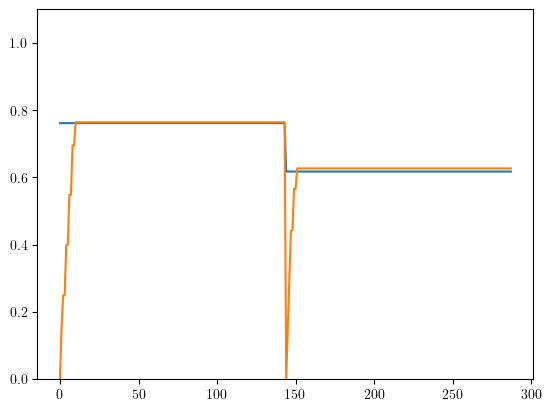

In [25]:
model = SAC.load('training_results/ems/ems/SAC/SAC_du_norm_1.zip')
actions1 = []
actions2 = []

h = 288
responses=np.zeros((env.observation_space.low.shape[-1], 288+1))
actions = np.zeros((2,288))
rewards = np.zeros(288)
s, _ = env.reset()
responses[:,0] = s  
for i in range(h):
    action = model.predict(s)[0]
    
    s, rew, d, w, info = env.step(action)
    responses[:,i+1] = s
    rewards[i] = rew
    actions[:,i] = action
    actions1.append(action[0])
    actions2.append(action[1])

plt.plot(responses[0,:-1], label='')
plt.plot(responses[1,:-1], label='')
plt.ylim([0,1.1])

In [60]:
model.learning_rate

0.0001

Text(0.5, 1.0, 'rewards: 132.24668694095809')

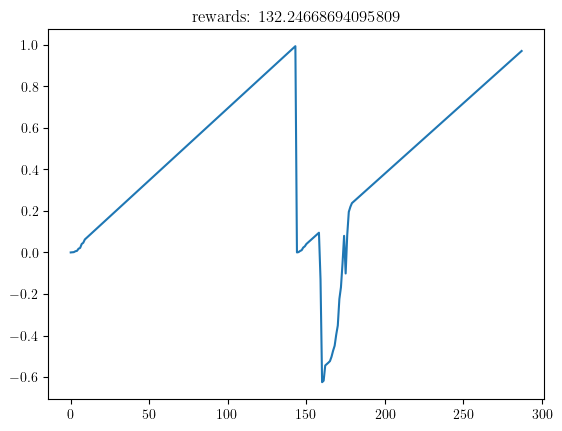

In [26]:
plt.plot(rewards)
plt.title(f"rewards: {np.sum(rewards)}")

In [29]:
def sat_cumsum(x):
    sum_ = 0
    y = np.zeros_like(x)
    for i in range(len(x)):
        sum_ += x[i]
        sum_ = np.clip(sum_,0,1)
        y[i] = sum_
    return y    

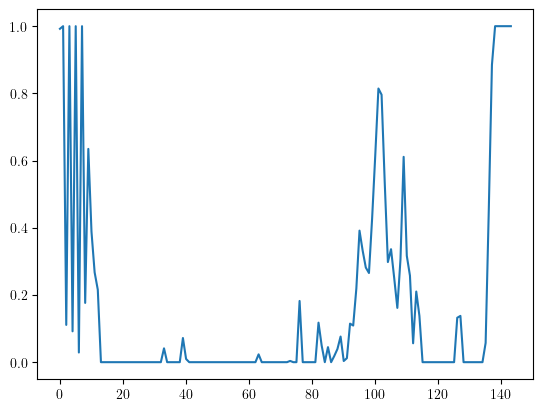

In [30]:
#plt.plot(responses[3,:288])
plt.plot(sat_cumsum(actions2[:144]))

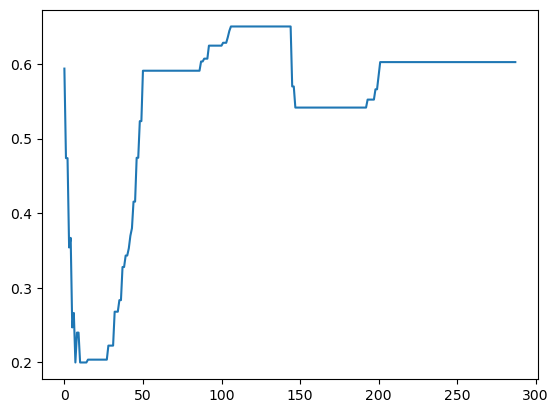

In [29]:
plt.plot(responses[3,:-1])

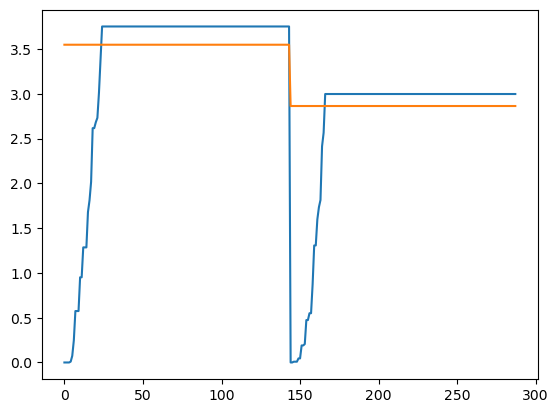

In [39]:
states, actions, rew = env.sample_trajectory(lambda x: model.predict(x)[0])
plt.plot(states[:-1,1])
plt.plot(states[:-1,0])

In [30]:
plt.plot(responses[:,7])
plt.plot(states[:,8])

NameError: name 'states' is not defined

In [29]:
T_inv = np.linalg.inv(env.transform)
env.show_sample(lambda x: model.predict(np.matmul(T_inv, x))[0])
fig = env.get_figure()
fig.savefig("agora_sim.png")

In [40]:
model.save("agora_sim")

In [9]:
import pandas as pd


In [11]:
stats = pd.read_csv(tmp_path+"/progress.csv")


(60.0, 100.0)

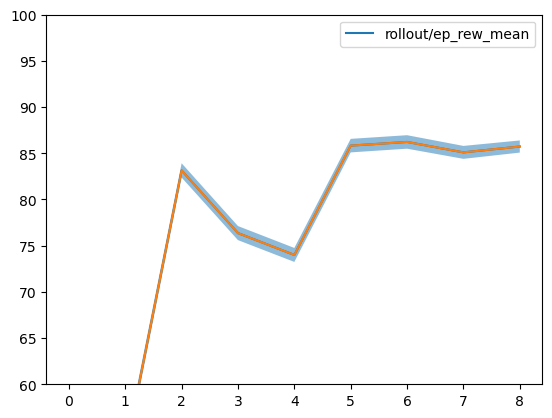

In [23]:
stats.plot(y = "rollout/ep_rew_mean")

ep_rwd_mean = stats["rollout/ep_rew_mean"]
ep_rwd_std = stats["train/std"]
plt.plot(ep_rwd_mean)
plt.fill_between(range(0,len(ep_rwd_mean)), ep_rwd_mean-ep_rwd_std, ep_rwd_mean+ep_rwd_std, alpha=0.5)
plt.ylim([60,100])

In [12]:
stats.head(5)

,time/total_timesteps,train/std,time/iterations,train/value_loss,train/clip_fraction,train/policy_gradient_loss,time/fps,time/time_elapsed,rollout/ep_len_mean,train/clip_range,train/entropy_loss,train/learning_rate,rollout/ep_rew_mean,train/loss,train/n_updates,train/explained_variance,train/approx_kl
0,20480,0.775678,10,49.735528,0.128174,-0.005355,851,24,288.0,0.2,-2.326335,0.001,-190.168983,26.457687,90,-0.000060,0.011725
1,40960,0.812221,20,14.223521,0.032471,-0.003240,848,48,288.0,0.2,-2.370625,0.001,52.562854,3.392765,190,0.556316,0.003907
2,61440,0.773654,30,7.484913,0.041406,-0.003579,848,72,288.0,0.2,-2.238383,0.001,83.145494,3.641592,290,0.921436,0.007175
3,81920,0.761908,40,8.960387,0.071094,-0.001853,846,96,288.0,0.2,-2.216065,0.001,76.361634,2.376076,390,0.900291,0.006660
4,102400,0.756763,50,3.808346,0.087549,-0.002487,820,124,288.0,0.2,-2.132692,0.001,73.997799,1.378352,490,0.920858,0.009830
